In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [3]:
import numpy as np
from loguru import logger
import pylab as plt

from stable_baselines3 import PPO

In [4]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj, save_obj
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler
from vimms.Roi import RoiBuilderParams

from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import run_method
from vimms_gym.common import METHOD_TOPN, METHOD_PPO
from vimms_gym.visualisation import plot_N, plot_ms1_ms2_counts, plot_action_hist, plot_action_probs, plot_reward_probs

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


# 1. Parameters

In [5]:
n_chemicals = (30000, 50000)
mz_range = (70, 1000)
rt_range = (0, 1440)
intensity_range = (1E4, 1E20)

In [6]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [7]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [8]:
mzml_filename = '../fullscan_QCB.mzML'
samplers = None
samplers_pickle = 'samplers_fullscan_QCB.mzML.p'
if exists(samplers_pickle):
    logger.info('Loaded %s' % samplers_pickle)
    samplers = load_obj(samplers_pickle)
    mz_sampler = samplers['mz']
    ri_sampler = samplers['rt_intensity']
    cr_sampler = samplers['chromatogram']
else:
    logger.info('Creating samplers from %s' % mzml_filename)
    mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
    ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                           min_log_intensity=min_log_intensity,
                                           max_log_intensity=max_log_intensity)
    roi_params = RoiBuilderParams(min_roi_length=3, at_least_one_point_above=1000)
    cr_sampler = MZMLChromatogramSampler(mzml_filename, roi_params=roi_params)
    samplers = {
        'mz': mz_sampler,
        'rt_intensity': ri_sampler,
        'chromatogram': cr_sampler
    }
    save_obj(samplers, samplers_pickle)

2022-05-26 22:56:56.193 | INFO     | __main__:<module>:5 - Loaded samplers_fullscan_QCB.mzML.p


In [9]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [10]:
max_peaks = 200
in_dir = 'results'

In [11]:
n_eval_episodes = 1
deterministic = True

# 2. Evaluation

## Generate some chemical sets

In [12]:
set_log_level_warning()

1

In [13]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0


## Run different methods

In [14]:
eval_dir = 'visualisation'

In [15]:
for chems in chem_list:
    print(len(chems))

41193


In [16]:
max_peaks

200

In [17]:
out_dir = eval_dir
in_dir, out_dir

('results', 'visualisation')

In [18]:
all_results = {}

In [19]:
env_name = 'DDAEnv'

### Run PPO

In [20]:
method = METHOD_PPO

In [21]:
model_name = 'PPO'

In [22]:
effective_rt_tol = rt_tol
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [23]:
fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
model = PPO.load(fname)

In [24]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, model=model, print_eval=True, print_reward=True)


Episode 0 (41193 chemicals)
steps	 500 	total rewards	 196.1330532739397
steps	 1000 	total rewards	 392.3493987770422
steps	 1500 	total rewards	 558.7164776093589
steps	 2000 	total rewards	 725.6596355017805
steps	 2500 	total rewards	 903.1258718053191
steps	 3000 	total rewards	 1063.3557989407775
steps	 3500 	total rewards	 1199.9784490402574
steps	 4000 	total rewards	 1328.2777038732238
steps	 4500 	total rewards	 1477.6775872287153
steps	 5000 	total rewards	 1630.3993828996868
steps	 5500 	total rewards	 1780.1936968873406
steps	 6000 	total rewards	 1937.6463633632566
Finished after 6324 timesteps with total reward 2022.7619087504133
{'coverage_prop': '0.233', 'intensity_prop': '0.161', 'ms1/ms2 ratio': '0.161', 'efficiency': '1.759', 'TP': '2406', 'FP': '729', 'FN': '38058', 'precision': '0.767', 'recall': '0.059', 'f1': '0.110'}


In [25]:
ppo_result = results[0]
ppo_result

### Run Top-N

In [26]:
method = METHOD_TOPN

In [27]:
effective_rt_tol = exclusion_t_0
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [28]:
model = None

In [29]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, N=10, model=model, print_eval=True, print_reward=True)


Episode 0 (41193 chemicals)
steps	 500 	total rewards	 167.36267176759418
steps	 1000 	total rewards	 325.2404488241011
steps	 1500 	total rewards	 488.9403273852879
steps	 2000 	total rewards	 639.0892130047353
steps	 2500 	total rewards	 806.9054121498391
steps	 3000 	total rewards	 967.9185797498172
steps	 3500 	total rewards	 1087.6320947554
steps	 4000 	total rewards	 1181.2558412047329
steps	 4500 	total rewards	 1287.8685181357832
steps	 5000 	total rewards	 1407.4623669752725
steps	 5500 	total rewards	 1536.351232883349
steps	 6000 	total rewards	 1655.748962877286
steps	 6500 	total rewards	 1775.0232724142568
Finished after 6587 timesteps with total reward 1790.8903335325163
{'coverage_prop': '0.228', 'intensity_prop': '0.160', 'ms1/ms2 ratio': '0.102', 'efficiency': '1.575', 'TP': '2228', 'FP': '561', 'FN': '38404', 'precision': '0.799', 'recall': '0.055', 'f1': '0.103'}


In [30]:
topN_result = results[0]
topN_result

# 3. Visualisation

## Visualise some results from the first episode

Limit some plots to the first 1000 steps.

In [31]:
limit = 1000

Plot the distribution of N: the number of MS2 scans that follow an MS1 scan

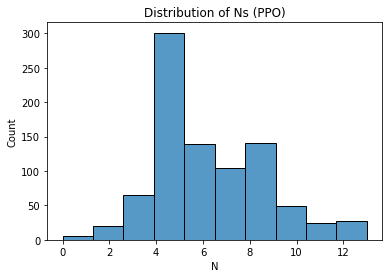

In [32]:
plot_N(ppo_result, bins=10, title='Distribution of Ns (PPO)')

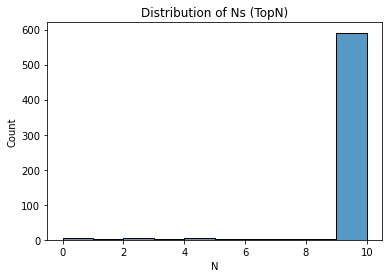

In [33]:
plot_N(topN_result, bins=10, title='Distribution of Ns (TopN)')

Plot the number of MS1 and MS2 scans over time

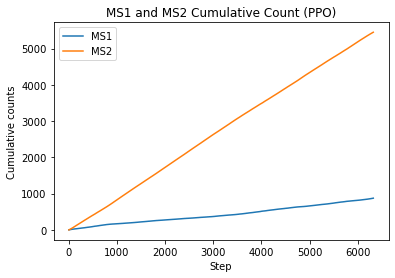

In [34]:
ppo_ms1, ppo_ms2 = plot_ms1_ms2_counts(ppo_result, title='MS1 and MS2 Cumulative Count (PPO)')

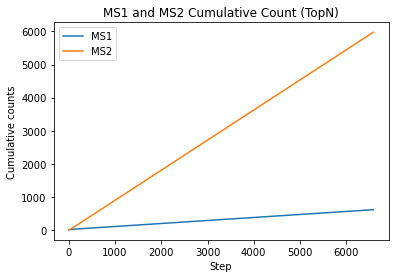

In [35]:
topN_ms1, topN_ms2 = plot_ms1_ms2_counts(topN_result, title='MS1 and MS2 Cumulative Count (TopN)')

Text(0.5, 1.0, 'MS2 Cumulative Counts')

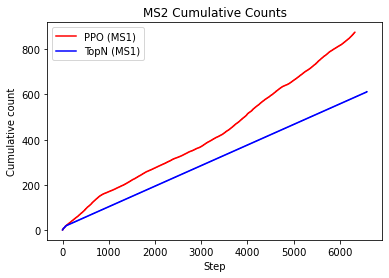

In [36]:
plt.plot(ppo_ms1, 'r-', label='PPO (MS1)')
plt.plot(topN_ms1, 'b-', label='TopN (MS1)')
plt.legend()
plt.ylabel('Cumulative count')
plt.xlabel('Step')
plt.title('MS2 Cumulative Counts')

Plot a histogram of all actions.

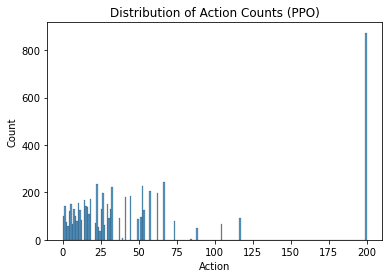

In [37]:
plot_action_hist(ppo_result, bins=200, title='Distribution of Action Counts (PPO)')

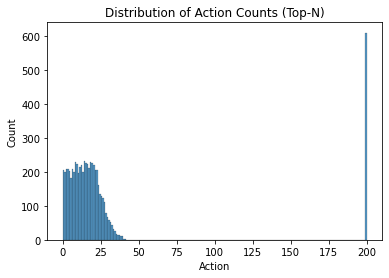

In [38]:
plot_action_hist(topN_result, bins=200, title='Distribution of Action Counts (Top-N)')

Plot a histogram of MS2-actions only

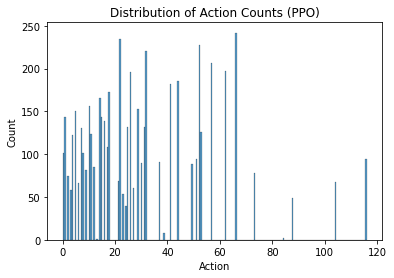

In [39]:
plot_action_hist(ppo_result, ms2_only=True, bins=199, title='Distribution of Action Counts (PPO)')

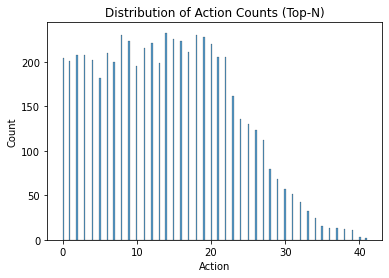

In [40]:
plot_action_hist(topN_result, ms2_only=True, bins=199, title='Distribution of Action Counts (Top-N)')

Show the first few actions

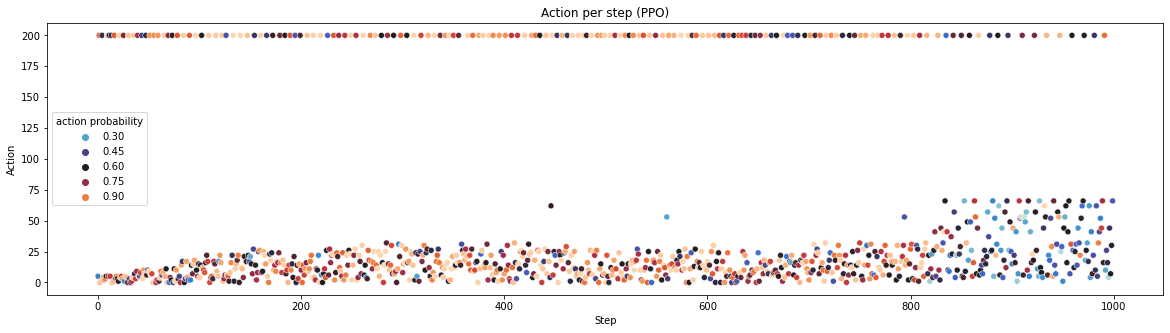

In [41]:
plot_action_probs(ppo_result, limit, max_peaks, title='Action per step (PPO)')

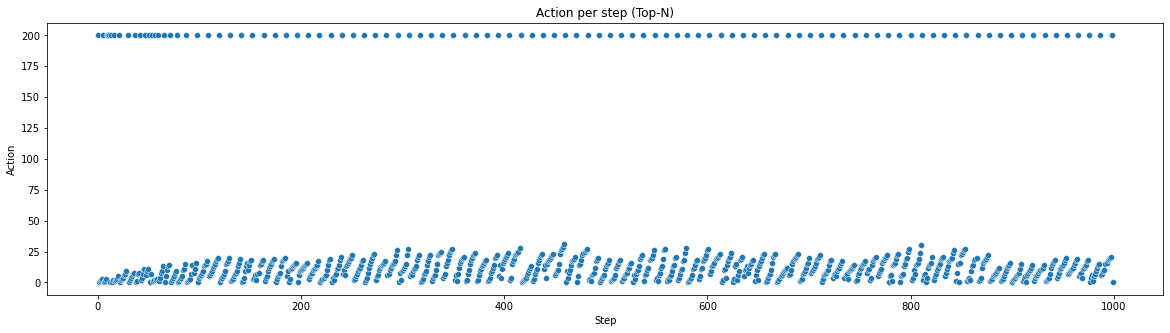

In [42]:
plot_action_probs(topN_result, limit, max_peaks, title='Action per step (Top-N)')

Plot rewards coloured by action probabilities

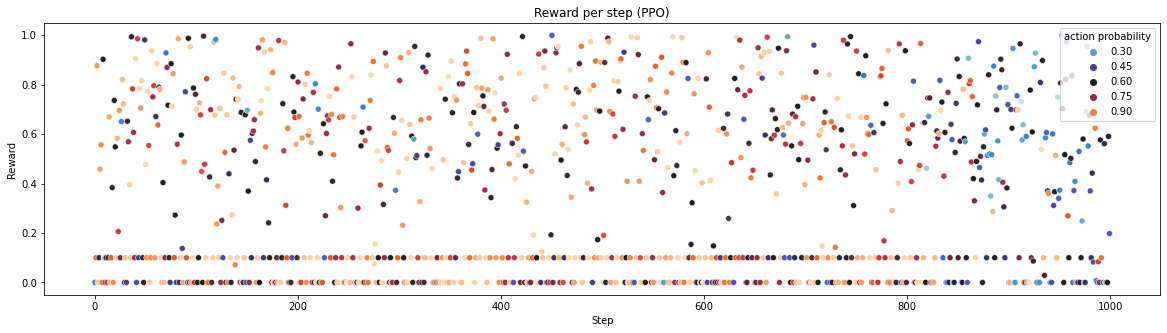

In [43]:
plot_reward_probs(ppo_result, limit, max_peaks, title='Reward per step (PPO)')

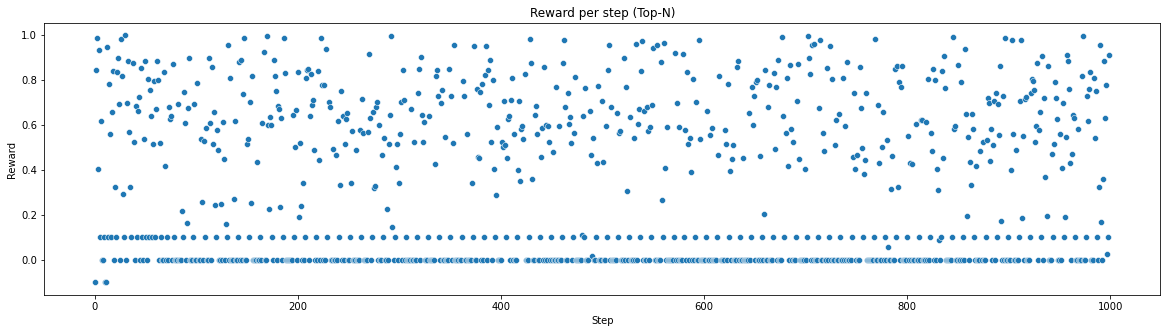

In [44]:
plot_reward_probs(topN_result, limit, max_peaks, title='Reward per step (Top-N)')